# ECON 5140: Applied Econometrics
## Homework 3: Causal Inference — Potential Outcomes & Matching

**Covers:** Lesson 7 (Potential Outcomes & DAGs) & Lesson 9 (Matching for Causal Inference)

---

# PART 1: ANALYTICAL PROBLEMS

### Problem 1: Potential Outcomes and Causal Estimands

Consider the following data from 8 individuals. D = 1 if they received job training; D = 0 if not. Y(1) and Y(0) are potential outcomes (earnings in thousands).

| i | Y(1) | Y(0) | D | Y_obs |
|---|------|------|---|-------|
| 1 | 45   | 35   | 1 | 45    |
| 2 | 50   | 42   | 1 | 50    |
| 3 | 38   | 40   | 0 | 40    |
| 4 | 55   | 48   | 1 | 55    |
| 5 | 42   | 38   | 0 | 38    |
| 6 | 48   | 45   | 1 | 48    |
| 7 | 40   | 44   | 0 | 44    |
| 8 | 52   | 46   | 0 | 46    |

**Questions:**

a) Calculate ATE, ATT, and ATU.

b) Calculate the Simple Difference in Outcomes (SDO) = E[Y|D=1] − E[Y|D=0]. Is SDO equal to ATE? Why or why not?

c) Decompose SDO into ATE + selection bias + HTE bias. Verify: SDO = ATE + (E[Y(0)|D=1] − E[Y(0)|D=0]) + p×(ATT − ATU).

d) If treatment were randomly assigned, what would happen to the SDO? Explain.

### Problem 2: DAGs — Confounding and Colliders

**Part (a)** Consider the DAG: D ← X → Y and D → Y, where D = treatment, Y = outcome, X = observed covariate.

- What is X called? Why does a naive comparison of D and Y (without controlling for X) produce bias?
- What adjustment would you make to estimate the causal effect of D on Y?

**Part (b)** Consider the DAG: D → X ← Y, where X is a collider.

- Are D and Y independent in the population? Explain.
- What happens if we condition on X? Why is this problematic?
- Give a real-world example of a collider (similar to the "admitted to elite university" example from lecture).

### Problem 3: Exact vs Approximate Matching

a) What is exact matching? When does it work well? What is the "curse of dimensionality" and why does it limit exact matching?

b) What is approximate (distance-based) matching? Name two distance metrics. How does nearest-neighbor matching work?

### Problem 4: Inverse Probability Weighting (IPW) — Numerical Example

Suppose we observe the following data. D = 1 if received job training, D = 0 if not. Y = earnings (thousands). The propensity score e(X) = Pr(D=1|X) has been estimated for each unit.

| i | D | Y  | e(X) |
|---|---|-----|------|
| 1 | 1 | 52 | 0.6  |
| 2 | 1 | 48 | 0.8  |
| 3 | 0 | 42 | 0.3  |
| 4 | 0 | 38 | 0.2  |
| 5 | 1 | 55 | 0.7  |
| 6 | 0 | 45 | 0.4  |

**Questions:**

a) **ATE weights:** For each unit i, the IPW weight for ATE is w_i = D_i/e(X_i) + (1−D_i)/(1−e(X_i)). Compute the weight for each of the 6 units. Fill in the table:

| i | D | Y  | e(X) | w_ATE |
|---|---|-----|------|-------|
| 1 | 1 | 52 | 0.6  | ?     |
| 2 | 1 | 48 | 0.8  | ?     |
| ... |   |    |      |       |

b) **ATT weights:** For ATT, treated units get weight 1; control units get weight w_i = e(X_i)/(1−e(X_i)). Compute the ATT weight for each unit. Fill in the table:

| i | D | Y  | e(X) | w_ATT |
|---|---|-----|------|-------|
| 1 | 1 | 52 | 0.6  | ?     |
| ... |   |    |      |       |

c) **ATE estimate:** Compute the IPW estimator for ATE:


d) **ATT estimate:** Compute the IPW estimator for ATT:



e) **Interpretation:** Which unit has the largest ATE weight? Why? (Hint: "Units unlikely to receive their observed treatment get larger weight.")

# PART 2: CODING PROBLEMS

## Problem 5: Propensity Score Model (Coding)

**Context (tech company):** A SaaS company rolled out an AI assistant feature in a phased rollout. Power users and higher-tier customers were more likely to get early access. You want to estimate the causal effect of the feature on **weekly active minutes**.

**Variables:**
- **D** = 1 if user had access to AI assistant, 0 otherwise
- **Y** = weekly_active_minutes (outcome)
- **plan_tier**: 0=free, 1=pro, 2=enterprise
- **tenure_days**: days since signup (0–365)
- **prior_sessions**: sessions in past 30 days before launch
- **platform**: 0=web, 1=mobile
- **signup_cohort**: 0=Q1, 1=Q2, 2=Q3 (quarter of signup)

**True causal effect:** +15 minutes per week. Treatment is *not* random—selection on observables.

**Your tasks:**

1. **Use the simulated data** below (or generate your own with the same DGP).

2. **Estimate the propensity score** e(X) = Pr(D=1|X) using logistic regression of D on all covariates. Print the model summary. Which covariates most increase the probability of treatment?

3. **Add fitted propensity scores** to the dataset.

4. **Check overlap:** Plot propensity score distributions for treated vs control (KDE or histogram). Is overlap sufficient?

5. **Compute ATE via IPW.** Compare naive ATE, IPW ATE, and true effect (15). Briefly interpret.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

np.random.seed(123)

# Simulated data: AI assistant feature rollout (phased, not random)
n = 600
plan_tier = np.random.choice([0, 1, 2], n, p=[0.5, 0.35, 0.15])
tenure_days = np.random.randint(0, 366, n)
prior_sessions = np.random.poisson(12, n) + np.random.randint(0, 20, n)
platform = np.random.choice([0, 1], n, p=[0.6, 0.4])
signup_cohort = np.random.choice([0, 1, 2], n, p=[0.4, 0.35, 0.25])

# Treatment: higher tier, tenure, prior sessions, mobile → more likely to get feature
logit_p = -2.0 + 0.5*plan_tier + 0.003*tenure_days + 0.02*prior_sessions + 0.4*platform + 0.2*signup_cohort
ps_true = 1 / (1 + np.exp(-np.clip(logit_p, -10, 10)))
D = (np.random.uniform(0, 1, n) < ps_true).astype(int)

# Outcome: weekly_active_minutes. True effect of feature = +15 min
Y = 80 + 15*D + 8*plan_tier + 0.05*tenure_days + 0.8*prior_sessions + 5*platform + 3*signup_cohort + np.random.normal(0, 12, n)
Y = np.maximum(Y, 0)

df = pd.DataFrame({
    'plan_tier': plan_tier, 'tenure_days': tenure_days, 'prior_sessions': prior_sessions,
    'platform': platform, 'signup_cohort': signup_cohort, 'D': D, 'weekly_active_minutes': Y
})

print("Dataset: AI assistant feature rollout")
print(f"  n = {len(df)}, Treated: {D.sum()}, Control: {n - D.sum()}")
print(f"  True causal effect: +15 min/week")
print(df.head(10))

Dataset: AI assistant feature rollout
  n = 600, Treated: 254, Control: 346
  True causal effect: +15 min/week
   plan_tier  tenure_days  prior_sessions  platform  signup_cohort  D  \
0          1          231              16         1              2  0   
1          0          276              28         0              2  0   
2          0          345              21         0              1  1   
3          1          353              23         0              1  1   
4          1           39              15         0              0  0   
5          0          205              28         0              0  0   
6          2          298              17         0              0  0   
7          1           58              31         0              0  1   
8          0           48              14         1              2  0   
9          0          174               9         0              2  0   

   weekly_active_minutes  
0             132.725826  
1             114.294894  
2   

In [11]:
# YOUR CODE for Problem 5
# Covariates: plan_tier, tenure_days, prior_sessions, platform, signup_cohort
# Outcome: weekly_active_minutes. True effect = 15

# 1. Logistic regression: D ~ covariates (propensity score model)
import statsmodels.api as sm

covariates = ["plan_tier", "tenure_days", "prior_sessions", "platform", "signup_cohort"]
X = sm.add_constant(df[covariates])
logit_model = sm.Logit(df["D"], X).fit(disp=False)
print(logit_model.summary())


                           Logit Regression Results                           
Dep. Variable:                      D   No. Observations:                  600
Model:                          Logit   Df Residuals:                      594
Method:                           MLE   Df Model:                            5
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                 0.04360
Time:                        18:44:06   Log-Likelihood:                -390.98
converged:                       True   LL-Null:                       -408.81
Covariance Type:            nonrobust   LLR p-value:                 1.115e-06
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.2951      0.371     -3.490      0.000      -2.022      -0.568
plan_tier          0.5289      0.118      4.472      0.000       0.297       0.761
tenure_days        0.0022      0.001

In [12]:
# Run the previous cell (logistic regression) first so `logit_model` and `X` exist.
df["ps"] = logit_model.predict(X)
print(df.groupby("D")["ps"].describe())

   count      mean       std       min       25%       50%       75%       max
D                                                                             
0  346.0  0.398390  0.107810  0.195181  0.316601  0.384065  0.470739  0.701222
1  254.0  0.457312  0.126529  0.207292  0.360795  0.447763  0.554149  0.786380


### Problem 5 — Overlap (task in prompt: plot propensity distributions)

**Question:** Plot fitted propensity scores for treated vs control (KDE or histogram). Assess whether **overlap** (common support) looks sufficient for weighting-based adjustment.


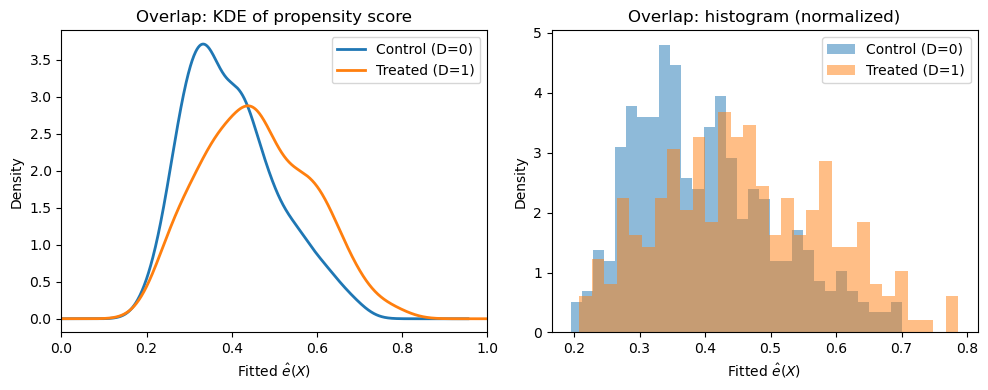

Overlap interval [max(min), min(max)] ≈ [0.207, 0.701]
Interpretation: Treated and control propensity scores largely share the same range; distributions overlap (no region where one group has almost all the mass). Overlap looks adequate for IPW, though some extreme ps may still need clipping when weighting.


In [13]:
# Run data + logit + df['ps'] cells first.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

for d, label, color in [(0, "Control (D=0)", "C0"), (1, "Treated (D=1)", "C1")]:
    df.loc[df["D"] == d, "ps"].plot.density(ax=ax1, label=label, color=color, lw=2)
ax1.set_xlabel(r"Fitted $\hat{e}(X)$")
ax1.set_ylabel("Density")
ax1.set_title("Overlap: KDE of propensity score")
ax1.set_xlim(0, 1)
ax1.legend()

ax2.hist(
    df.loc[df["D"] == 0, "ps"],
    bins=30,
    density=True,
    alpha=0.5,
    label="Control (D=0)",
    color="C0",
)
ax2.hist(
    df.loc[df["D"] == 1, "ps"],
    bins=30,
    density=True,
    alpha=0.5,
    label="Treated (D=1)",
    color="C1",
)
ax2.set_xlabel(r"Fitted $\hat{e}(X)$")
ax2.set_ylabel("Density")
ax2.set_title("Overlap: histogram (normalized)")
ax2.legend()
plt.tight_layout()
plt.show()

# Common support: compare ranges
lo = max(df.loc[df["D"] == 0, "ps"].min(), df.loc[df["D"] == 1, "ps"].min())
hi = min(df.loc[df["D"] == 0, "ps"].max(), df.loc[df["D"] == 1, "ps"].max())
print(f"Overlap interval [max(min), min(max)] ≈ [{lo:.3f}, {hi:.3f}]")
print(
    "Interpretation: Treated and control propensity scores largely share the same range; "
    "distributions overlap (no region where one group has almost all the mass). "
    "Overlap looks adequate for IPW, though some extreme ps may still need clipping when weighting."
)


### Problem 5 — IPW estimate of ATE (clipped propensity scores)

**Question:** Compute the average treatment effect using **inverse probability weighting**, clipping $\hat{e}(X)$ to $[\varepsilon, 1-\varepsilon]$ so weights stay finite. Compare the **naive** difference in means, the **IPW** ATE, and the **true** effect (+15 min/week).

**Two standard IPW ATE estimators (both use the same clipped $\hat{e}$):**
- **Horvitz–Thompson:** $\frac{1}{n}\sum_i\bigl(\frac{D_i Y_i}{\hat{e}_i} - \frac{(1-D_i)Y_i}{1-\hat{e}_i}\bigr)$ — matches the ATE weight $w_i = D_i/\hat{e}_i + (1-D_i)/(1-\hat{e}_i)$ from lecture when written as an average.
- **Hajek (stabilized):** ratio of weighted means — often used in applied work because it can behave better in finite samples.


In [15]:
# Requires prior cells: df with D, weekly_active_minutes, ps (same seed as data cell)
Y = df["weekly_active_minutes"]
D = df["D"]

ate_naive = Y[D == 1].mean() - Y[D == 0].mean()

df["ps_clip"] = df["ps"].clip(0.01, 0.99)
pc = df["ps_clip"]

# Horvitz–Thompson IPW ATE (same structure as ChatGPT / lecture weights)
ipw_ate_ht = np.mean(D * Y / pc - (1 - D) * Y / (1 - pc))

# Hajek (stabilized) IPW ATE
mu1 = (D * Y / pc).sum() / (D / pc).sum()
mu0 = ((1 - D) * Y / (1 - pc)).sum() / ((1 - D) / (1 - pc)).sum()
ipw_ate_hajek = mu1 - mu0

true_ate = 15.0

print(f"Naive ATE (difference in means):        {ate_naive:8.3f}")
print(f"IPW ATE — Horvitz–Thompson (clipped ps): {ipw_ate_ht:8.3f}")
print(f"IPW ATE — Hajek stabilized (clipped ps): {ipw_ate_hajek:8.3f}")
print(f"True causal effect (simulation):         {true_ate:8.3f}")
print()
print(
    "Naive ATE confounds the +15 effect with selection on X. "
    "HT and Hajek are both valid IPW estimators; they need not match each other in finite samples. "
    "Re-run the data cell without changing the seed if you need numbers to match a write-up exactly."
)


Naive ATE (difference in means):          18.798
IPW ATE — Horvitz–Thompson (clipped ps):   16.497
IPW ATE — Hajek stabilized (clipped ps):   15.333
True causal effect (simulation):           15.000

Naive ATE confounds the +15 effect with selection on X. HT and Hajek are both valid IPW estimators; they need not match each other in finite samples. Re-run the data cell without changing the seed if you need numbers to match a write-up exactly.


### Problem 5 — Task 5: Compare naive ATE, IPW ATE, and true effect

**Question:** Summarize the **naive** difference in means, **IPW** estimate(s), and the **true** causal effect (+15 min/week). How far is each estimate from the truth, and why does naive differ from IPW?


In [ ]:
# Run the IPW cell above first (needs ate_naive, ipw_ate_ht, ipw_ate_hajek, true_ate)

compare = pd.DataFrame(
    {
        "Method": [
            "Naive (E[Y|D=1] − E[Y|D=0])",
            "IPW — Hajek (stabilized)",
            "IPW — Horvitz–Thompson",
            "True ATE (simulation)",
        ],
        "Estimate": [ate_naive, ipw_ate_hajek, ipw_ate_ht, true_ate],
    }
)
compare["Error vs true (15)"] = compare["Estimate"] - true_ate
compare["|Error|"] = compare["Error vs true (15)"].abs()

print(compare.to_string(index=False))
print()
print(
    "Naive ATE is large because treated users are positively selected on X (e.g. higher plan "
    "tier, mobile) and those same factors also raise Y even without the AI feature—so simple "
    "comparison of group means mixes the true +15 effect with confounding."
)
print(
    "IPW uses estimated propensity scores to reweight toward a pseudo-population where "
    "treatment is independent of observed X; under this DGP, IPW (especially Hajek) is much "
    "closer to 15 than naive, though Monte Carlo noise and imperfect e(X) still leave small bias."
)
